In [1]:
# Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
# Load Breast Cancer Dataset

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(data.target)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
# Dataset Information

print("Dataset Shape:", X.shape)

X.head()

Dataset Shape: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# Target Distribution

print(y.value_counts())

print("\nClass Names:")
print(data.target_names)

1    357
0    212
Name: count, dtype: int64

Class Names:
['malignant' 'benign']


In [5]:
# Split Dataset into Training and Testing Data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (455, 30)
Testing Data: (114, 30)


In [6]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


In [7]:
# Baseline Logistic Regression Model

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(
    X_train_scaled,
    y_train
)

print("Baseline Model Trained Successfully")

Baseline Model Trained Successfully


In [8]:
# Baseline Prediction

baseline_pred = baseline_model.predict(X_test_scaled)

## Evaluation Function

In [9]:
def evaluate_model(name, y_true, y_pred):
    
    print("Model:", name)
    print("-----------------------")
    
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

## Baseline Evaluation

In [10]:
evaluate_model(
    "Logistic Regression Baseline",
    y_test,
    baseline_pred
)

Model: Logistic Regression Baseline
-----------------------
Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1 Score: 0.9861111111111112

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## Random Forest Model

In [11]:
# Random Forest Model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [12]:
# Random Forest Prediction

rf_pred = rf_model.predict(X_test)

In [13]:
evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

Model: Random Forest
-----------------------
Accuracy: 0.956140350877193
Precision: 0.958904109589041
Recall: 0.9722222222222222
F1 Score: 0.9655172413793104

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## Gradient Boosting Model 

In [14]:
# Gradient Boosting Model

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

print("Gradient Boosting Model Trained Successfully")

Gradient Boosting Model Trained Successfully


In [15]:
# Gradient Boosting Prediction

gb_pred = gb_model.predict(X_test)

In [16]:
evaluate_model(
    "Gradient Boosting",
    y_test,
    gb_pred
)

Model: Gradient Boosting
-----------------------
Accuracy: 0.956140350877193
Precision: 0.9466666666666667
Recall: 0.9861111111111112
F1 Score: 0.9659863945578231

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## Model Comparision

In [17]:
# Model Comparison

comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],

    "Precision": [
        precision_score(y_test, baseline_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],

    "Recall": [
        recall_score(y_test, baseline_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],

    "F1 Score": [
        f1_score(y_test, baseline_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ]
})


comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
1,Random Forest,0.956140,0.958904,0.972222,0.965517
2,Gradient Boosting,0.956140,0.946667,0.986111,0.965986


## Best Model Identification

In [18]:
# Best Model Based on F1 Score

best_model = comparison.loc[
    comparison["F1 Score"].idxmax()
]

print("Best Performing Model:")
best_model

Best Performing Model:


Model        Logistic Regression
Accuracy                0.982456
Precision               0.986111
Recall                  0.986111
F1 Score                0.986111
Name: 0, dtype: object

## Hyperparameter Tunning Using GridSearchCV

In [19]:
# Hyperparameter Tuning using GridSearchCV

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(rf_grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


## Best Tuned Random Forest Model

In [20]:
# Best Tuned Random Forest Model

tuned_rf_model = rf_grid_search.best_estimator_

tuned_rf_pred = tuned_rf_model.predict(X_test)

print("Tuned Random Forest Performance:")
evaluate_model(
    "Tuned Random Forest",
    y_test,
    tuned_rf_pred
)

Tuned Random Forest Performance:
Model: Tuned Random Forest
-----------------------
Accuracy: 0.956140350877193
Precision: 0.958904109589041
Recall: 0.9722222222222222
F1 Score: 0.9655172413793104

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [21]:
# Add Tuned Random Forest to Comparison

tuned_rf_results = pd.DataFrame({
    "Model": ["Tuned Random Forest"],
    "Accuracy": [accuracy_score(y_test, tuned_rf_pred)],
    "Precision": [precision_score(y_test, tuned_rf_pred)],
    "Recall": [recall_score(y_test, tuned_rf_pred)],
    "F1 Score": [f1_score(y_test, tuned_rf_pred)]
})

final_comparison = pd.concat(
    [comparison, tuned_rf_results],
    ignore_index=True
)

final_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
1,Random Forest,0.956140,0.958904,0.972222,0.965517
2,Gradient Boosting,0.956140,0.946667,0.986111,0.965986
3,Tuned Random Forest,0.956140,0.958904,0.972222,0.965517


## Random Forest Cross Validation

In [22]:
# 5-Fold Cross Validation - Random Forest

rf_cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("Random Forest Cross-Validation F1 Scores:")
print(rf_cv_scores)

print("\nMean F1 Score:", rf_cv_scores.mean())
print("Standard Deviation:", rf_cv_scores.std())

Random Forest Cross-Validation F1 Scores:
[0.93617021 0.95238095 0.98611111 0.97260274 0.9787234 ]

Mean F1 Score: 0.9651976840478735
Standard Deviation: 0.018341287238906344


## Gradient Boosting Cross Validation

In [23]:
# 5-Fold Cross Validation - Gradient Boosting

gb_cv_scores = cross_val_score(
    gb_model,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("Gradient Boosting Cross-Validation F1 Scores:")
print(gb_cv_scores)

print("\nMean F1 Score:", gb_cv_scores.mean())
print("Standard Deviation:", gb_cv_scores.std())

Gradient Boosting Cross-Validation F1 Scores:
[0.94285714 0.95890411 0.97931034 0.98611111 0.98591549]

Mean F1 Score: 0.9706196402685257
Standard Deviation: 0.017073295204551926


## Tuned Random Forest Cross Validation

In [24]:
# 5-Fold Cross Validation - Tuned Random Forest

tuned_rf_cv_scores = cross_val_score(
    tuned_rf_model,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("Tuned Random Forest Cross-Validation F1 Scores:")
print(tuned_rf_cv_scores)

print("\nMean F1 Score:", tuned_rf_cv_scores.mean())
print("Standard Deviation:", tuned_rf_cv_scores.std())

Tuned Random Forest Cross-Validation F1 Scores:
[0.93617021 0.95238095 0.98611111 0.97931034 0.9787234 ]

Mean F1 Score: 0.9665392050681852
Standard Deviation: 0.019064878910432834


## Feature Importance Extract

In [25]:
# Feature Importance from Tuned Random Forest

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tuned_rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
22,worst perimeter,0.133100
23,worst area,0.128052
27,worst concave points,0.108107
7,mean concave points,0.094414
20,worst radius,0.090639
0,mean radius,0.058662
2,mean perimeter,0.055242
3,mean area,0.049938
6,mean concavity,0.046207
26,worst concavity,0.035357


## Visualize Top 10 Features

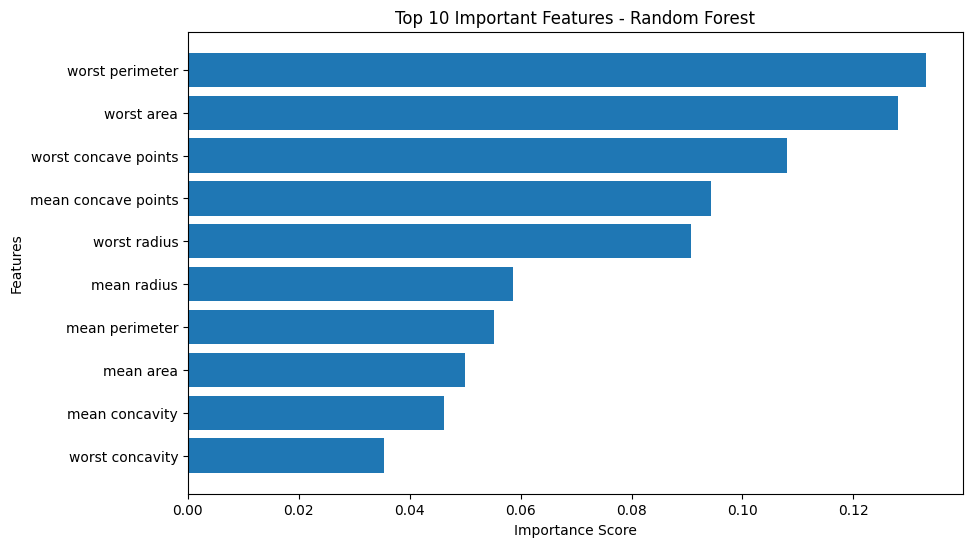

In [26]:
# Plot Top 10 Important Features

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"].head(10),
    feature_importance["Importance"].head(10)
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Important Features - Random Forest")

plt.gca().invert_yaxis()

plt.show()

## Final Model Selection

In [27]:
# Final Model Selection

final_model = final_comparison.loc[
    final_comparison["F1 Score"].idxmax()
]

print("Final Selected Model:")
final_model

Final Selected Model:


Model        Logistic Regression
Accuracy                0.982456
Precision               0.986111
Recall                  0.986111
F1 Score                0.986111
Name: 0, dtype: object

## Save Best Model

In [28]:
import joblib

joblib.dump(
    tuned_rf_model,
    "best_random_forest_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


## Conclusion



In this task, an ensemble learning based machine learning workflow was implemented using the Breast Cancer dataset.

Multiple classification models including Logistic Regression, Random Forest, and Gradient Boosting were trained and evaluated.

Random Forest optimization was performed using Hyperparameter Tuning with GridSearchCV, and model reliability was evaluated using Cross Validation.

Feature Importance analysis was performed to understand the contribution of different features in model prediction.

Based on evaluation metrics such as Accuracy, Precision, Recall, and F1 Score, the best performing model was selected.

This task provided practical understanding of ensemble learning techniques, model optimization, and building a reliable machine learning pipeline.